# Fundamentals of Machine Learning Modeling with the Iris Dataset and Decision Trees

Author: Iman Mossavat, Fontys University of Applied Sciences, 2025

In this notebook, we focus on one of the **most fundamental concepts in machine learning**: choosing the **right complexity for a model**. This is at the heart of understanding **overfitting and underfitting** (also called the **bias–variance trade-off**).  

We use **decision trees** as our example model. A decision tree learns to classify samples by asking a sequence of **hierarchical yes/no questions** on the features. Its behavior is controlled by **hyperparameters**, such as `max_depth`, which limit how complex the tree can become. Hyperparameters are not learned from the data—they define the **model’s capacity** and allow us to balance simplicity and flexibility.

Instead of focusing only on abstract metrics or numbers, this notebook emphasizes **visual understanding**:  

- We visualize **decision trees** to see the rules they learn.
- We plot **decision boundaries** to observe how the model separates classes.
- We examine **feature importance and distributions** to understand which inputs matter most.

By working visually, we aim to **see, reason, and interpret** the model’s behavior, making abstract concepts like capacity, overfitting, and underfitting much more tangible and intuitive.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap


### Load the Dataset (Improved Explanation)

Here we load the **Iris dataset**, one of the most classic and widely used datasets in machine learning.
It contains **150 flower samples** from three different species of iris:

* *Iris setosa*
* *Iris versicolor*
* *Iris virginica*

Each sample has **four numerical features**:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

Our goal is to train a model that predicts the species from these measurements.




In [2]:

iris = load_iris()
X, y = iris.data, iris.target
X.shape, y.shape



((150, 4), (150,))

### Note on the Iris Object

The `iris` variable is a **dictionary-like object** (specifically a `sklearn.utils.Bunch`).
It behaves similarly to a Python dictionary, and you can inspect its **keys** to understand what information it contains.

* The **`data`** key stores the feature matrix (the four measurements for each flower).
* The **`target`** key stores the species labels encoded as integers (`0`, `1`, `2`).
* Other keys include metadata such as feature names, target names, and a dataset description.

You can explore all available keys like this:

```python
iris.keys()
```

And you can inspect the contents of any key—for example:

```python
iris['feature_names']
iris['target_names']
iris['DESCR']
```

Try investigating these fields to get a better understanding of how the dataset is structured.



In [3]:
iris.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Next, we **split the dataset into training and testing sets**.
This is critical because:

* The **training set** is used to fit (learn) the model
* The **test set** is used to evaluate how well the model generalizes to **new, unseen data**
* If we trained and evaluated on the same data, we would get an overly optimistic estimate (overfitting risk)

We also apply **stratification** using the target labels `y`.
Stratification means the split preserves the **class proportions** in both the train and test sets.
This is important for small datasets like Iris (only 150 samples), because without stratification you could accidentally end up with uneven class distributions—hurting training stability and test reliability.

In summary:

* We split into train and test sets to measure generalization
* We use stratification to maintain balanced class proportions in both splits

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X.shape, X_train.shape, X_test.shape

((150, 4), (105, 4), (45, 4))

### Train/Test Split and Stratification (Improved Explanation)

Next, we split the dataset into a **training set** and a **test set**.
This is one of the **most important concepts in all of machine learning** because it lies at the heart of **overfitting vs. underfitting**, also known more formally as the **bias–variance trade-off**. We will explore this idea more deeply later with hands-on examples.

* The **training set** is used for learning patterns from the data.
* The **test set** represents **new, unseen data** and tells us how well the model *generalizes*.
* If we trained and tested on the same data, the model could simply memorize the answers, giving an overly optimistic performance estimate—this is the essence of **overfitting**.

We also use **stratification** based on the target labels `y`.
This ensures that the **class proportions remain the same** in both the training and test sets.
Since the Iris dataset has 150 samples (50 per species), stratification prevents splits where one species becomes under-represented, which would lead to unstable training or misleading evaluation.

**In summary:**

* We split data to properly measure generalization.
* We stratify to preserve class balance and avoid skewed splits.
* This train/test setup is foundational to understanding overfitting, underfitting, and the bias–variance trade-off—concepts we will explore in detail later.

---
# Fit a Decision Tree

A Decision Tree is a model that maps input features (here, the flower measurements) to output labels (species) by learning a series of hierarchical rules. It splits the data based on feature values, creating a tree-like structure where each branch represents a decision, and each leaf represents a predicted class.

The fit method trains the tree using the training data, finding the splits that best separate the classes. Later, we can use this tree to make predictions for new samples.

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



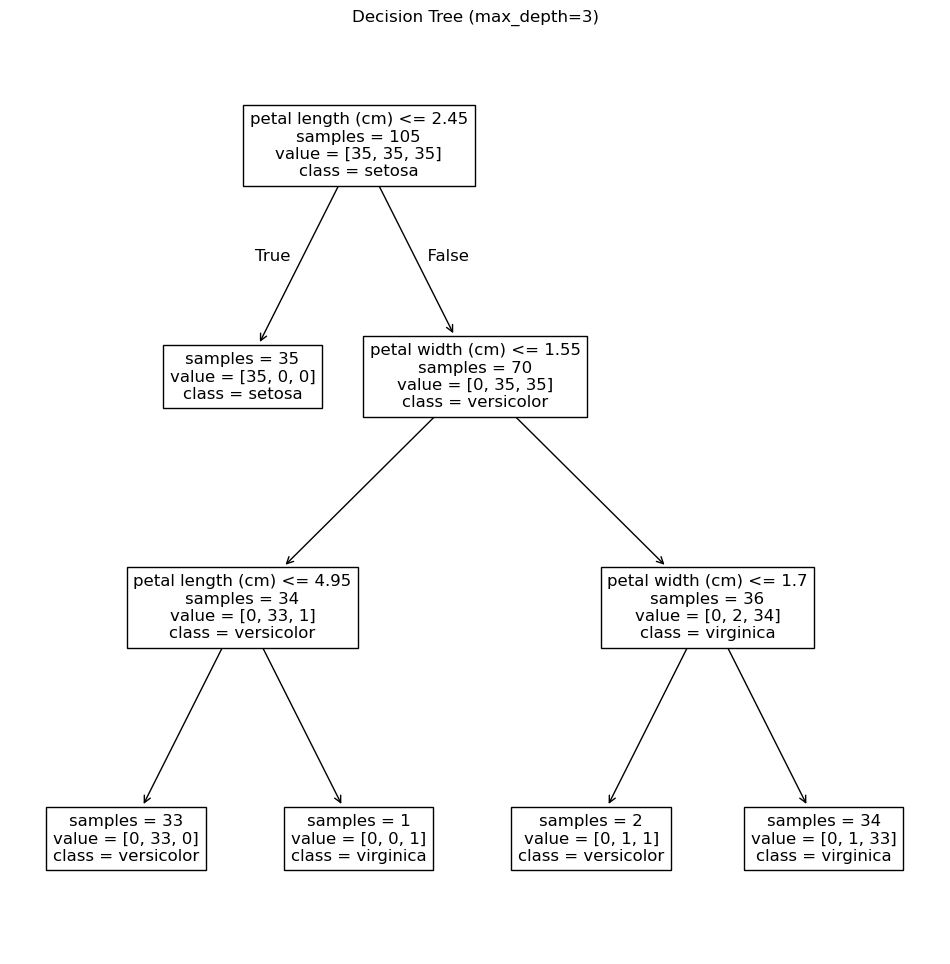

In [7]:

from sklearn.tree import export_text
depth= 3
clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
clf.fit(X_train, y_train)

tree_text = export_text(clf, feature_names=iris.feature_names)
print(tree_text)

plt.figure(figsize=(12, 12))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=False,        # no color fills
    impurity=False,      # hide Gini
    proportion=False,    # hide proportions
    precision=2,         # cleaner thresholds
)
plt.title(f"Decision Tree (max_depth={depth})")
plt.show()

### Understanding the Decision Tree Output

The printed tree text gives a simple, readable description of how the Decision Tree makes decisions. Each line corresponds to a **node** in the tree, and each node contains a **threshold condition** such as:

```
petal width (cm) <= 0.80
petal length (cm) <= 4.85
```

These thresholds are **not chosen by us**—the model automatically finds them by analyzing the training data and searching for the splits that best separate the species.

At each step, the tree asks a **yes/no question** about one feature.
A simplified version of what happens inside training:

1. The algorithm tries all features (sepal length, sepal width, petal length, petal width).
2. For each feature, it tries many possible thresholds from the training data.
3. It chooses the threshold that best separates the classes (using a metric like **Gini impurity**).
4. It splits the data into two groups and repeats the process on each group, until the maximum depth is reached.

So when you see something like:

```
petal width (cm) <= 0.80
```

this means the tree discovered that 0.80 is a good point to separate some species (e.g., setosa vs. the rest).

The leaf nodes at the bottom show the **predicted class** once no further splitting is allowed (here up to depth 3).

The tree diagram visualizes the exact same rules, but in a more intuitive branching form.

If you want to read more about how these thresholds are found mathematically, look up the scikit-learn documentation for:

* `DecisionTreeClassifier`
* `criterion="gini"`
* impurity-based splitting

The key idea is:
**the model learns a sequence of threshold-based rules that splits the data into increasingly pure groups, eventually assigning a class label at each leaf.**

TO DO: Try to match the thresholds on the plot and the printed text.

---
## Feature Importances

Decision Trees let us see **which features the model relied on most** to separate the classes. After training, scikit-learn provides a feature importance score for each measurement.

In the plot below, you can see that `petal length` and `petal width` have the highest importance values. These two features are the most informative for distinguishing iris species, while **sepal length** and **sepal width** contribute very little—they are not very useful for separating the classes.

You can confirm this by looking back at the decision tree visualization.

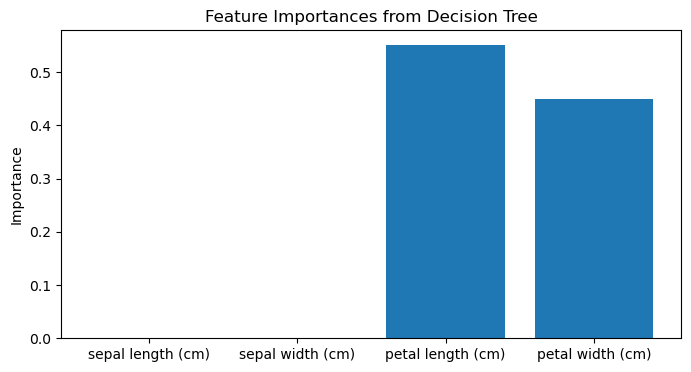

array([0.        , 0.        , 0.55087719, 0.44912281])

In [8]:

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

importances = clf.feature_importances_

plt.figure(figsize=(8,4))
plt.bar(iris.feature_names, importances)
plt.title("Feature Importances from Decision Tree")
plt.ylabel("Importance")
plt.show()

importances


### Boxplots: Visualizing Feature Separation Across Species

We can confirm the feature importances in another way: by **visualizing each feature for each species** using boxplots.
If a feature shows **little or no overlap** between species (for example, petal length and petal width), then that feature alone can separate them well.
For the Iris dataset—being simple and well-structured—some species are almost perfectly separable using just a **single feature**.

However, real-world datasets are usually more complex. In those cases, no single feature is enough, and models must combine **multiple features** to separate classes effectively.

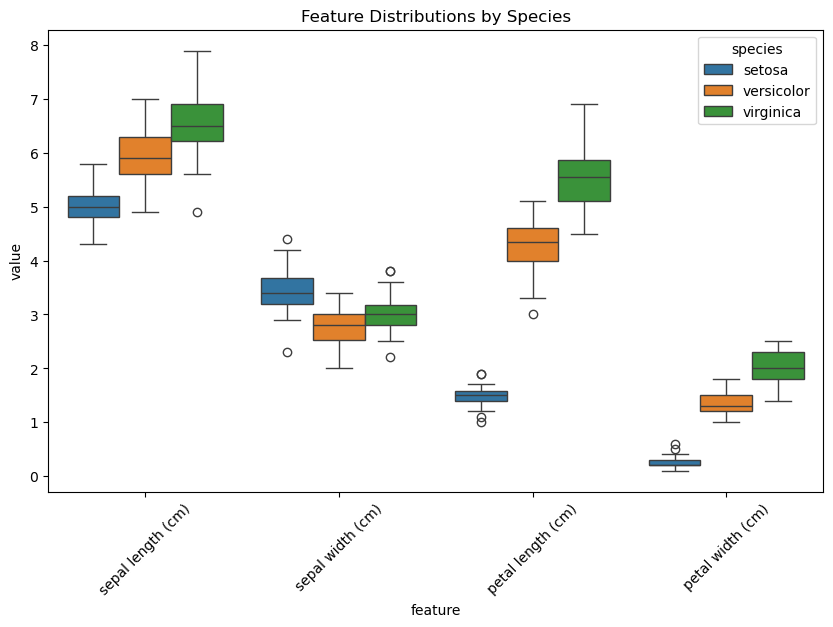

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build a DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in y]

# Melt into long format for a single sns command
df_melt = df.melt(id_vars="species", var_name="feature", value_name="value")

# One seaborn command for all boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melt, x="feature", y="value", hue="species")
plt.title("Feature Distributions by Species")
plt.xticks(rotation=45)
plt.show()


A boxplot is a simple way to see how a feature’s values are distributed:

The box shows the middle 50% of the values.

The line inside the box shows the median (middle value).

The whiskers show the range of most of the data.

Points outside the whiskers are unusual values (outliers).

Here, we use boxplots to compare each feature across the three iris species. If the boxes don’t overlap, that feature can easily separate the species.

# Plotting Decision Boundaries (Using Only the Important Features)

Now that we’ve seen **petal length** and **petal width** are the most informative features, we can **visualize how a decision tree splits the feature space**.
By restricting ourselves to only these two features, we can draw the **actual decision boundaries** that the tree learned.

A decision boundary plot shows:

* how the classifier divides the 2D space into regions
* which regions correspond to each species
* how increasing `max_depth` makes the boundaries more jagged and specific
  (this is exactly how overfitting happens!)

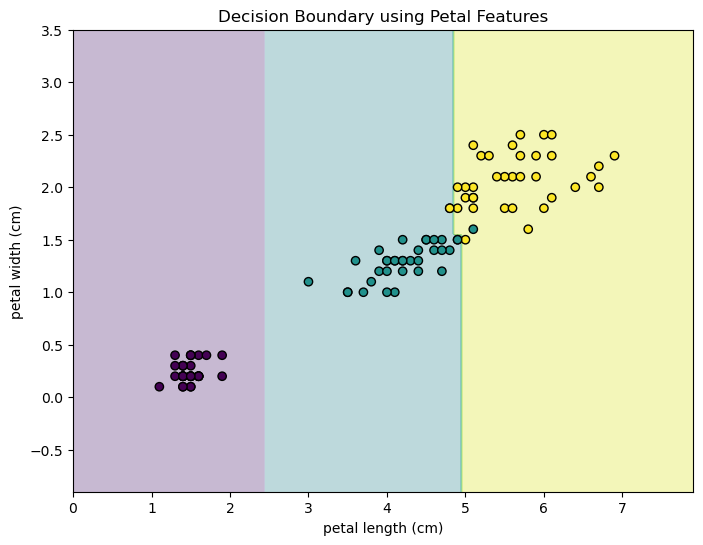

In [10]:
max_depth= 3
# Use last two features for visualization (petal length, petal width)
X2 = X[:, 2:]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y
)

clf2 = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
clf2.fit(X2_train, y2_train)

# Create a grid for visualization
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, edgecolors="k")
plt.xlabel(iris.feature_names[2])   # Petal length
plt.ylabel(iris.feature_names[3])   # Petal width
plt.title("Decision Boundary using Petal Features")
plt.show()

### To do

Change max_depth (e.g., 1, 2, 3, 5, 8).

* Small depth → simple, smooth boundaries → may underfit

* Large depth → complex, jagged boundaries → may overfit

Observe how the shapes change.
Decision trees create axis-aligned splits (vertical/horizontal lines), so the boundaries will look like rectangular regions.

Try comparing:

the tree visualization

the decision boundary plot

---
## Train and Test accuracy, and assessing learning and generalization

We compare training accuracy and test accuracy.
(See the earlier section for the full explanation of why this matters.)

If the training accuracy is much higher than the test accuracy, the model is likely overfitting.
If both accuracies are low, we are underfitting.
If they are similar and reasonably high, the model is generalizing well.

In [11]:
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

train_acc, test_acc

(0.9809523809523809, 0.9777777777777777)

## Sweep max_depth to show overfitting and underfitting



### Sweeping `max_depth`: Model Capacity (complexity), Overfitting, and Underfitting

A Decision Tree has a key parameter, **`max_depth`**, which controls the model’s **capacity**—how complex the learned rules can become.

* A **larger depth** allows the tree to create more splits and more detailed decision boundaries.
  This can improve training accuracy but also risks **overfitting** (memorizing the training data instead of learning general patterns).

* A **smaller depth** forces the model to use simpler rules.
  If it’s too simple, the model cannot capture the structure of the data, leading to **underfitting**.

By sweeping over different depths and plotting **train vs. test accuracy**, we can directly see this trade-off:
as depth increases, training accuracy typically rises, but test accuracy may peak and then decline when the model becomes too complex.

This visualization makes the **capacity–overfitting–underfitting relationship** very clear.


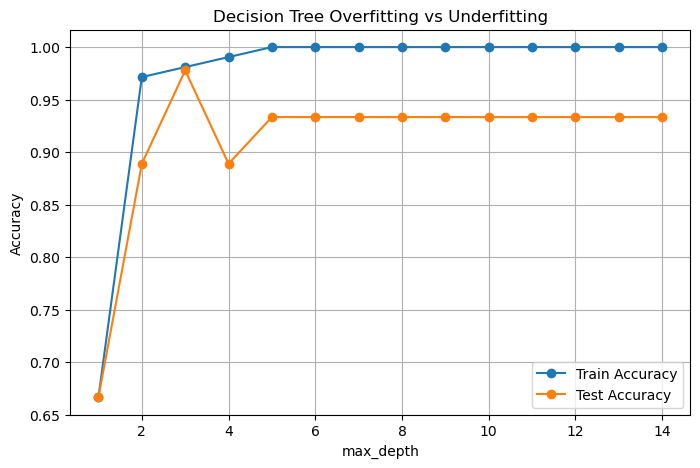

In [92]:

depths = range(1, 15)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, marker='o', label="Train Accuracy")
plt.plot(depths, test_scores, marker='o', label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting vs Underfitting")
plt.legend()
plt.grid(True)
plt.show()


### Key Takeaways

1. **Train/Test Split & Stratification**
   - Splitting data ensures we evaluate models on **unseen data**, preventing overly optimistic estimates.
   - Stratification preserves class proportions in both training and test sets.

2. **Decision Trees**
   - Trees split features using thresholds to create hierarchical rules.
   - Each leaf corresponds to a predicted class.

3. **Feature Importance**
   - Trees can tell us which features are most useful for classification.
   - In Iris, petal length and petal width are most informative.

4. **Overfitting vs. Underfitting**
   - Depth controls model capacity:
     - Too shallow → underfitting (cannot capture patterns)
     - Too deep → overfitting (memorizes training data)
   - Sweeping max_depth shows the trade-off between training and test accuracy.

5. **Decision Boundaries**
   - Visualizing boundaries in 2D illustrates how the tree separates classes.
   - Axis-aligned splits create rectangular regions.
   - Boundary complexity grows with depth, showing overfitting visually.

6. **Confirming Insights**
   - Boxplots show feature distributions per species.
   - Highly separable features align with those the tree found most important.


---
# Final To-Do

1. Explore the **Iris dataset**:
   - Inspect the `iris` keys and contents.
   - Look at `feature_names`, `target_names`, and `DESCR`.

2. Train and evaluate a **decision tree**:
   - Fit the tree on training data.
   - Compare training and test accuracy.
   - Assess if the model is overfitting, underfitting, or generalizing well.

3. Visualize the **tree structure**:
   - Use `export_text` and `plot_tree`.
   - Observe the thresholds and features at top nodes.

4. Investigate **feature importance**:
   - Plot importance values.
   - Verify that top features match the splits in the tree.

5. Use **boxplots** to inspect feature separability:
   - Confirm which features clearly separate species.
   - Compare with feature importance.

6. Explore **decision boundaries**:
   - Plot boundaries using the top two features.
   - Experiment with different `max_depth` values.
   - Observe how boundary complexity changes with depth.

7. Sweep **max_depth**:
   - Plot training vs. test accuracy across depths.
   - Identify regions of underfitting, good fit, and overfitting.
